# 13 — Ingeniero, modelo y producción real: 2026

**Pregunta:** ¿el sistema de ajuste teórico con respaldo mejora el estimado del ingeniero sobre exactamente los mismos casos?

**Entradas:** base de casos de 10 y `estimados_semanales_limpio.parquet`, generado por la limpieza oficial 03. Se conserva la lógica de los benchmarks originales: unión estricta y recuperación por variedad sólo cuando los pendientes son inequívocos. No se releen cachés Excel ni se suman entregas distintas.

Se evalúan todos los orígenes locales de 2026 con producción objetivo observada en 2026. El modelo se reentrena al primer origen disponible de cada mes con semanas cerradas, usando los mismos parámetros fijados en 12. Esto amplía sus bloques de evaluación; no es una nueva búsqueda de hiperparámetros. La comparación principal exige coincidencia comercial estricta y archivo no posterior. Las recuperaciones por color y archivos posteriores se muestran separadamente.

La unidad del ingeniero es ESTI. EXPORTABLE y la del target tallos reportados: su equivalencia sigue pendiente. La fecha nominal tampoco certifica publicación. El resultado es una comparación retrospectiva condicional, no una prueba operativa definitiva de superioridad.

In [1]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from threadpoolctl import threadpool_limits

ROOT = next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/"Datos_analiticos_proyecto").is_dir())
SALIDA = ROOT/"Datos_analiticos_proyecto"

KEY=['finca','producto','color','variedad']
DESTINO=SALIDA/'modelo_con_proyecciones_teoricas'
integrados=pd.read_parquet(DESTINO/'base_analitica_proyecciones.parquet')
datos=integrados.loc[integrados.y.notna()&integrados.admisible_modelo].copy()
categoricas=['producto','color','variedad']
temporales=['horizonte','semana_seno','semana_coseno']
memoria=['produccion_lag1','produccion_lag2','produccion_lag3','media_4','media_8','desv_4','tendencia_4_8','cambio_reciente','produccion_52']
climaticas=[v+s for v in ['temperatura_semana','humedad_semana','radiacion_semana'] for s in ['_lag1','_media4']]
agronomicas=[]
X_columnas=categoricas+temporales+memoria+climaticas
X_teoria=X_columnas+['teoria_modelo','antiguedad_curva','desviacion_reciente_teoria']
X_historia=X_teoria+['teoria_previa_1','teoria_previa_2','revision_teoria']
assert 'y' not in X_historia
assert not integrados.duplicated(KEY+['origen','horizonte']).any()


In [2]:
CORTES = [pd.Timestamp("2025-07-07"),pd.Timestamp("2026-01-05"),pd.Timestamp("2026-05-04")]
SEMANAS_EVALUACION = 8

def crear_modelo(nombre,columnas):
    numericas = [c for c in columnas if c not in categoricas]
    numerico = make_pipeline(SimpleImputer(strategy="median",add_indicator=True,keep_empty_features=True),
                             StandardScaler()) if nombre.startswith("Ridge") else SimpleImputer(
                                 strategy="median",add_indicator=True,keep_empty_features=True)
    preparar = ColumnTransformer([
        ("categorias",OneHotEncoder(handle_unknown="ignore",sparse_output=False,dtype=np.float32),categoricas),
        ("numericas",numerico,numericas)])
    estimador = Ridge(alpha=100.0) if nombre.startswith("Ridge") else HistGradientBoostingRegressor(
        learning_rate=.08,max_iter=80,max_leaf_nodes=15,min_samples_leaf=40,
        l2_regularization=1.0,early_stopping=False,random_state=42)
    return make_pipeline(preparar,estimador)
print("Sesgo positivo = el modelo quedó por debajo de lo reportado.")
print("±8% procede del Plan de Proyecto; es referencia inicial, no aprobación operativa.")


Sesgo positivo = el modelo quedó por debajo de lo reportado.
±8% procede del Plan de Proyecto; es referencia inicial, no aprobación operativa.


## 1. Predicciones temporales para 2026

Se mantiene el modelo que ajusta teoría completa; cuando no existe se utiliza ajuste de media4. No se selecciona la variante ganadora usando 2026. Se conservan origen, fecha de entrenamiento y ruta utilizada.

In [3]:
llave=KEY+['origen','semana_objetivo','horizonte']
universo=integrados.loc[integrados.origen.dt.year.eq(2026)&integrados.semana_objetivo.dt.year.eq(2026)&integrados.y.notna()].copy()
evaluables=universo.loc[universo.admisible_modelo].copy()
preds=[]; entrenamiento=[]
for mes,t in evaluables.groupby(evaluables.origen.dt.to_period('M'),sort=True):
    corte=t.origen.min()
    train=datos.loc[(datos.semana_objetivo+pd.Timedelta(days=7)).le(corte)]
    tc=train.loc[train.curva_completa]
    assert len(tc)>0 and train.semana_objetivo.max()+pd.Timedelta(days=7)<=corte
    previo=crear_modelo('Boosting_ajuste_media4',X_columnas)
    nuevo=crear_modelo('Boosting_ajuste_teoria',X_teoria)
    t=t.copy()
    with threadpool_limits(limits=2):
        previo.fit(train[X_columnas],train.y-train.media_4)
        nuevo.fit(tc[X_teoria],tc.y-tc.teoria_modelo)
        t['modelo']=np.maximum(0,t.media_4+previo.predict(t[X_columnas]))
        completa=t.curva_completa
        if completa.any():t.loc[completa,'modelo']=np.maximum(0,t.loc[completa,'teoria_modelo']+nuevo.predict(t.loc[completa,X_teoria]))
    t['ruta']=np.where(t.curva_completa,'ajuste_teoria','respaldo_media4')
    t['corte_entrenamiento']=corte
    preds.append(t[llave+['y','modelo','ruta','teoria_modelo','corte_entrenamiento']])
    entrenamiento.append({'mes':str(mes),'corte':corte,'train':len(train),'train_teoria':len(tc),'test':len(t)})
    print(mes,'casos:',len(t),flush=True)
predicciones=pd.concat(preds,ignore_index=True)
assert not predicciones.duplicated(llave).any()
assert predicciones.corte_entrenamiento.le(predicciones.origen).all()
assert np.isfinite(predicciones.modelo).all() and predicciones.modelo.ge(0).all()
display(pd.DataFrame(entrenamiento))


2026-01 casos: 2404


2026-02 casos: 2363


2026-03 casos: 2927


2026-04 casos: 2268


2026-05 casos: 2329


2026-06 casos: 2828


2026-07 casos: 2297


2026-08 casos: 1758


,mes,corte,train,train_teoria,test
0,2026-01,2026-01-05,123537,39836,2404
1,2026-02,2026-02-02,125942,40275,2363
2,2026-03,2026-03-02,128320,40552,2927
3,2026-04,2026-04-06,131265,40834,2268
4,2026-05,2026-05-04,133560,41036,2329
5,2026-06,2026-06-01,135874,41163,2828
6,2026-07,2026-07-06,138715,41318,2297
7,2026-08,2026-08-03,140994,41463,1758


## 2. Estimados del ingeniero y conservación de pendientes

Una cantidad faltante en alguna línea invalida la suma para las métricas, aunque el valor parcial se conserve. La recuperación se decide contra **toda la producción observada**, antes de restringir a las series que el modelo puede predecir. Así no se transforma una ambigüedad real entre colores en una falsa coincidencia única.

Origen solicitado y semana objetivo deben coincidir con el caso del modelo. Una entrega posterior se mantiene como reconstrucción descriptiva separada, nunca como entrega conocida al origen.

In [4]:
e=pd.read_parquet(SALIDA/'estimados_semanales_limpio.parquet')
e=e.loc[e.finca.eq('GAITANA')&e.en_h1_h5&~e.es_ajustado&e.origen_solicitado.dt.year.eq(2026)&e.semana_inicio.dt.year.eq(2026)].copy()
e=e.rename(columns={'origen_solicitado':'origen','semana_inicio':'semana_objetivo'})
assert e.groupby(llave).archivo_origen.nunique().le(1).all()
assert ((e.semana_objetivo-e.origen).dt.days==7*(e.horizonte-1)).all()
g=e.groupby(llave,dropna=False)
ingeniero=g.agg(ingeniero=('estimado','sum'),lineas=('estimado','size'),cantidades=('estimado','count'),archivo=('archivo_origen','first'),posterior=('archivo_es_posterior','max'),origen_archivo=('origen_nominal','first')).reset_index()
ingeniero['completo']=ingeniero.lineas.eq(ingeniero.cantidades)
ingeniero.loc[ingeniero.cantidades.eq(0),'ingeniero']=np.nan
ingeniero['id_estimado']=np.arange(len(ingeniero))
reales=universo[llave+['y']].copy()
assert not reales.duplicated(llave).any()
estricta=reales.merge(ingeniero,on=llave,how='left',validate='one_to_one',indicator=True)
coinciden=estricta.loc[estricta._merge.eq('both')].drop(columns='_merge').copy()
coinciden['metodo_union']='estricta'
coinciden['color_ingeniero']=coinciden.color
rp=estricta.loc[estricta._merge.eq('left_only'),llave+['y']]
ep=ingeniero.loc[~ingeniero.id_estimado.isin(coinciden.id_estimado)]
sin_color=[c for c in llave if c!='color']
ru=rp.loc[~rp.duplicated(sin_color,keep=False)]
eu=ep.loc[~ep.duplicated(sin_color,keep=False)].rename(columns={'color':'color_ingeniero'})
recuperadas=ru.merge(eu,on=sin_color,how='inner',validate='one_to_one')
recuperadas['metodo_union']='variedad_unica'
parejas=pd.concat([coinciden,recuperadas],ignore_index=True)
assert not parejas.duplicated(llave).any()
assert not parejas.id_estimado.duplicated().any()
auditoria=predicciones.merge(parejas.drop(columns='y'),on=llave,how='left',validate='one_to_one')
assert len(auditoria)==len(predicciones)
assert auditoria.y.sum()==predicciones.y.sum()
condiciones=[auditoria.id_estimado.isna(),~auditoria.completo.fillna(False).astype(bool),auditoria.posterior.fillna(False).astype(bool),auditoria.metodo_union.eq('variedad_unica')]
auditoria['grupo_comparacion']=np.select([c.to_numpy(dtype=bool,na_value=False) for c in condiciones],['sin_pareja','cantidad_incompleta','archivo_posterior','recuperacion_color'],default='principal_estricta_nominal')
display(auditoria.groupby(['grupo_comparacion','horizonte']).agg(casos=('y','size'),real_por_caso=('y','sum')))
display(pd.DataFrame({'universo_observado':[len(universo)],'modelo_disponible':[len(predicciones)],'ingeniero_emparejado':[auditoria.id_estimado.notna().sum()],'principal':[auditoria.grupo_comparacion.eq('principal_estricta_nominal').sum()]}))
print('Estimados sin pareja con producción observada:',len(ingeniero)-len(parejas))


casos  real_por_caso
grupo_comparacion          horizonte                      
archivo_posterior          1.0          224        2482941
                           2.0          224        2511579
                           3.0          223        2814963
                           4.0          220        2412657
                           5.0          217        2770647
principal_estricta_nominal 1.0         3413       43114174
                           2.0         3289       42079208
                           3.0         3166       40558233
                           4.0         3045       39433648
                           5.0         2925       37987912
recuperacion_color         1.0          232         967855
                           2.0          224         936793
                           3.0          216         894650
                           4.0          208         854791
                           5.0          200         817845
sin_pareja                 1.0          270         108536
                           2.0          244          99732
                           3.0          230          92787
                           4.0          211          83903
                           5.0          193          75351

,universo_observado,modelo_disponible,ingeniero_emparejado,principal
0,26690,19174,18026,15838


Estimados sin pareja con producción observada: 6828


## 3. Comparación emparejada y cobertura

WAPE = suma de errores absolutos / suma de reales. Sesgo positivo significa subestimación. Los dos métodos se puntúan en los mismos casos. Se informa por horizonte, mes, producto, color, variedad y ruta; no comparar métricas calculadas sobre poblaciones distintas.

n          MAE         RMSE  \
grupo_comparacion          metodo                                         
archivo_posterior          ingeniero   1108.0  2383.762635  4149.247355   
                           modelo      1108.0  2765.733675  5180.393135   
principal_estricta_nominal ingeniero  15838.0  2531.724839  4403.875315   
                           modelo     15838.0  2611.320270  4738.766762   
recuperacion_color         ingeniero   1080.0   998.284259  1366.569209   
                           modelo      1080.0  1005.772361  1326.595947   

                                          WAPE        sesgo  dentro_8pct  
grupo_comparacion          metodo                                         
archivo_posterior          ingeniero  0.203283   894.804152     0.212996  
                           modelo     0.235856   485.999423     0.202166  
principal_estricta_nominal ingeniero  0.197356  1250.135497     0.217262  
                           modelo     0.203561   657.444768     0.218651  
recuperacion_color         ingeniero  0.241092   515.147222     0.199074  
                           modelo     0.242900  -119.485858     0.191667

n          MAE         RMSE      WAPE        sesgo  \
horizonte metodo                                                               
1.0       ingeniero  3413.0  2158.891005  3727.656625  0.170902   955.342807   
          modelo     3413.0  2155.914880  3885.729143  0.170666   572.566707   
2.0       ingeniero  3289.0  2467.040438  4271.206690  0.192829  1045.368805   
          modelo     3289.0  2361.570198  4342.929487  0.184585   690.224251   
3.0       ingeniero  3166.0  2602.472205  4469.143353  0.203151  1211.956096   
          modelo     3166.0  2648.602445  4823.495656  0.206751   627.527007   
4.0       ingeniero  3045.0  2707.974384  4686.461443  0.209105  1466.321182   
          modelo     3045.0  2930.223423  5263.036199  0.226267   747.867042   
5.0       ingeniero  2925.0  2779.438632  4878.863188  0.214012  1640.629744   
          modelo     2925.0  3051.194158  5361.611253  0.234936   657.875850   

                     dentro_8pct  
horizonte metodo                  
1.0       ingeniero     0.239379  
          modelo        0.244360  
2.0       ingeniero     0.219216  
          modelo        0.241107  
3.0       ingeniero     0.209097  
          modelo        0.218888  
4.0       ingeniero     0.208210  
          modelo        0.195402  
5.0       ingeniero     0.207521  
          modelo        0.187350

n          MAE         RMSE      WAPE        sesgo  \
mes     metodo                                                               
2026-01 ingeniero  1640.0  2600.040244  4577.884013  0.222252  1135.296341   
        modelo     1640.0  2858.473723  5215.203126  0.244343   833.868455   
2026-02 ingeniero  2119.0  2717.351581  4570.406771  0.215239  1997.038226   
        modelo     2119.0  2950.935507  5224.623506  0.233741  1040.306287   
2026-03 ingeniero  2568.0  2866.958723  5354.799141  0.191633  1109.007788   
        modelo     2568.0  2779.736377  5435.686867  0.185802   620.423141   
2026-04 ingeniero  1486.0  2704.843203  4656.771018  0.194298  1154.281965   
        modelo     1486.0  2785.670034  4362.866554  0.200104 -1011.061053   
2026-05 ingeniero  1989.0  3329.294620  5370.479461  0.255668  2751.099548   
        modelo     1989.0  2579.953135  4294.095588  0.198123  1546.179616   
2026-06 ingeniero  2461.0  2346.831369  3871.300045  0.194959  1116.806989   
        modelo     2461.0  2498.142744  4381.008044  0.207529   405.096011   
2026-07 ingeniero  2015.0  1756.685856  2803.652754  0.146949   254.083375   
        modelo     2015.0  2446.911310  4876.509245  0.204688  1020.114580   
2026-08 ingeniero  1560.0  1766.882051  2840.160103  0.148858   263.117949   
        modelo     1560.0  1877.762912  3322.494865  0.158200   398.733097   

                   dentro_8pct  
mes     metodo                  
2026-01 ingeniero     0.179878  
        modelo        0.178049  
2026-02 ingeniero     0.182161  
        modelo        0.182633  
2026-03 ingeniero     0.240654  
        modelo        0.249611  
2026-04 ingeniero     0.242261  
        modelo        0.202557  
2026-05 ingeniero     0.126697  
        modelo        0.202112  
2026-06 ingeniero     0.212515  
        modelo        0.233239  
2026-07 ingeniero     0.294293  
        modelo        0.229280  
2026-08 ingeniero     0.265385  
        modelo        0.258974

n          MAE         RMSE      WAPE  \
producto       metodo                                                  
ACHILLEA       ingeniero   155.0    34.212903    40.454594  0.998118   
               modelo      155.0   255.352070   291.176453  7.449571   
AMAZON         ingeniero   155.0   521.387097   616.674249  0.221614   
               modelo      155.0   766.325423   915.013822  0.325725   
BARBATUS       ingeniero   775.0   444.445161   568.699382  0.285350   
               modelo      775.0   534.310438   673.110705  0.343047   
CARNATION      ingeniero  5825.0  1432.569957  2009.531548  0.224297   
               modelo     5825.0  1525.663654  2248.375914  0.238873   
GREEN BALL     ingeniero   155.0  1438.903226  1661.893401  0.185370   
               modelo      155.0  1499.102027  1915.221266  0.193125   
MINICARNATION  ingeniero  4567.0  4800.339391  7133.819640  0.177519   
               modelo     4567.0  5110.642266  7879.576960  0.188995   
RAFFINE        ingeniero   945.0  3804.116402  5363.926476  0.293590   
               modelo      945.0  3019.060896  4707.588337  0.233002   
SOLOMIO        ingeniero  1860.0  2271.765591  3289.132639  0.185386   
               modelo     1860.0  2266.523467  3099.862381  0.184958   
STAR           ingeniero   158.0  2577.088608  3243.925174  0.207502   
               modelo      158.0  2294.957595  2916.837855  0.184785   
STATICE        ingeniero   475.0   378.768421   548.026286  0.360692   
               modelo      475.0   354.937591   514.909014  0.337999   
TRACHELIUM     ingeniero   148.0  1914.527027  2317.156094  0.473568   
               modelo      148.0  1750.161512  2183.395121  0.432911   
VERONICA       ingeniero   310.0   915.287097  1060.223265  0.343886   
               modelo      310.0   739.111525   966.563073  0.277695   
VERONICA SPRAY ingeniero   310.0   649.796774   847.494145  0.261648   
               modelo      310.0   767.392545  1003.290467  0.309000   

                                sesgo  dentro_8pct  
producto       metodo                               
ACHILLEA       ingeniero    33.374194     0.006452  
               modelo     -247.720365     0.000000  
AMAZON         ingeniero    -9.322581     0.187097  
               modelo     -249.853218     0.096774  
BARBATUS       ingeniero    37.077419     0.158710  
               modelo     -144.088443     0.125161  
CARNATION      ingeniero   565.728755     0.213562  
               modelo      155.576994     0.205837  
GREEN BALL     ingeniero  -237.225806     0.245161  
               modelo     -699.631688     0.290323  
MINICARNATION  ingeniero  2470.211955     0.266915  
               modelo     2095.303032     0.262755  
RAFFINE        ingeniero  1783.705820     0.123810  
               modelo      251.523596     0.197884  
SOLOMIO        ingeniero  1472.979570     0.264516  
               modelo       44.653724     0.256989  
STAR           ingeniero  2423.569620     0.139241  
               modelo       71.509499     0.265823  
STATICE        ingeniero    54.242105     0.120000  
               modelo      -58.065123     0.145263  
TRACHELIUM     ingeniero  1298.445946     0.074324  
               modelo      193.329006     0.108108  
VERONICA       ingeniero   475.951613     0.058065  
               modelo     -125.202978     0.183871  
VERONICA SPRAY ingeniero   172.183871     0.225806  
               modelo     -193.233558     0.187097

n          MAE         RMSE      WAPE  \
ruta            metodo                                                   
ajuste_teoria   ingeniero   1442.0  1823.688627  2974.335142  0.211804   
                modelo      1442.0  1781.791288  3209.864941  0.206938   
respaldo_media4 ingeniero  14396.0  2602.646499  4522.236284  0.196416   
                modelo     14396.0  2694.411462  4865.511708  0.203341   

                                 sesgo  dentro_8pct  
ruta            metodo                               
ajuste_teoria   ingeniero   938.003467     0.199029  
                modelo      673.878525     0.211512  
respaldo_media4 ingeniero  1281.400736     0.219089  
                modelo      655.798653     0.219366

n         MAE         RMSE  \
producto       color      metodo                                      
ACHILLEA       LIGHT PINK ingeniero   60.0   25.966667    31.848077   
                          modelo      60.0  263.723627   299.121559   
               RED        ingeniero   35.0   18.657143    22.393239   
                          modelo      35.0  252.002038   287.725415   
               YELLOW     ingeniero   60.0   51.533333    54.046276   
...                                    ...         ...          ...   
VERONICA       WHITE      modelo     155.0  968.610590  1186.277282   
VERONICA SPRAY PURPLE     ingeniero  155.0  748.045161   951.753089   
                          modelo     155.0  805.002256  1098.027470   
               WHITE      ingeniero  155.0  551.548387   728.463252   
                          modelo     155.0  729.782835   898.620719   

                                          WAPE       sesgo  dentro_8pct  
producto       color      metodo                                         
ACHILLEA       LIGHT PINK ingeniero   0.981108   25.966667     0.000000  
                          modelo      9.964369 -260.390294     0.000000  
               RED        ingeniero   0.956076   18.657143     0.028571  
                          modelo     12.913721 -251.144895     0.000000  
               YELLOW     ingeniero   1.016437   49.366667     0.000000  
...                                        ...         ...          ...  
VERONICA       WHITE      modelo      0.346888  -94.986196     0.096774  
VERONICA SPRAY PURPLE     ingeniero   0.308931   33.851613     0.200000  
                          modelo      0.332453 -221.631067     0.212903  
               WHITE      ingeniero   0.216672  310.516129     0.251613  
                          modelo      0.286690 -164.836049     0.161290  

[152 rows x 6 columns]

n  \
finca   producto  color            variedad             metodo             
GAITANA ACHILLEA  LIGHT PINK       SASSY SUMMER TAFFY   ingeniero   60.0   
                                                        modelo      60.0   
                  RED              SASSY SUMMER SANGRIA ingeniero   35.0   
                                                        modelo      35.0   
                  YELLOW           SASSY SUMMER LEMON   ingeniero   60.0   
                                                        modelo      60.0   
        AMAZON    PURPLE           NEON PURPLE          ingeniero  155.0   
                                                        modelo     155.0   
        BARBATUS  HOT PINK         WONDER               ingeniero  155.0   
                                                        modelo     155.0   
                  LAVENDER         MELIAN               ingeniero  155.0   
                                                        modelo     155.0   
                  LIGHT PINK       NOBLE                ingeniero  155.0   
                                                        modelo     155.0   
                  RED              AMRAS                ingeniero  155.0   
                                                        modelo     155.0   
                  WHITE            HERA                 ingeniero  155.0   
                                                        modelo     155.0   
        CARNATION BICOLOR BURGUNDY PERFECT              ingeniero  155.0   
                                                        modelo     155.0   
                  BICOLOR PINK     SPRITZ BIANCO ROSA   ingeniero  155.0   
                                                        modelo     155.0   
                  BICOLOR PURPLE   DAMASCUS             ingeniero  155.0   
                                                        modelo     155.0   
                                   KINO                 ingeniero  155.0   
                                                        modelo     155.0   
                  BICOLOR RED      SORRISO              ingeniero  155.0   
                                                        modelo     155.0   
                  BICOLOR YELLOW   CONFERENCE           ingeniero   15.0   
                                                        modelo      15.0   
                                   SPRITZ               ingeniero  155.0   
                                                        modelo     155.0   
                                   ZENIT                ingeniero  155.0   
                                                        modelo     155.0   
                  BURGUNDY         ZURIGO               ingeniero  155.0   
                                                        modelo     155.0   
                  CREAM            HALO                 ingeniero  155.0   
                                                        modelo     155.0   
                                   POLIMNIA             ingeniero  155.0   
                                                        modelo     155.0   

                                                                           MAE  \
finca   producto  color            variedad             metodo                   
GAITANA ACHILLEA  LIGHT PINK       SASSY SUMMER TAFFY   ingeniero    25.966667   
                                                        modelo      263.723627   
                  RED              SASSY SUMMER SANGRIA ingeniero    18.657143   
                                                        modelo      252.002038   
                  YELLOW           SASSY SUMMER LEMON   ingeniero    51.533333   
                                                        modelo      248.934698   
        AMAZON    PURPLE           NEON PURPLE          ingeniero   521.387097   
                                                        modelo      766.325423   
        BARBATUS  HOT PINK         WONDER               in

,modelo,principal,observados,pct_principal_sobre_observados
horizonte,,,,
1.0,4139,3413,5755,59.304952
2.0,3981,3289,5544,59.325397
3.0,3835,3166,5334,59.355081
4.0,3684,3045,5127,59.391457
5.0,3535,2925,4930,59.330629


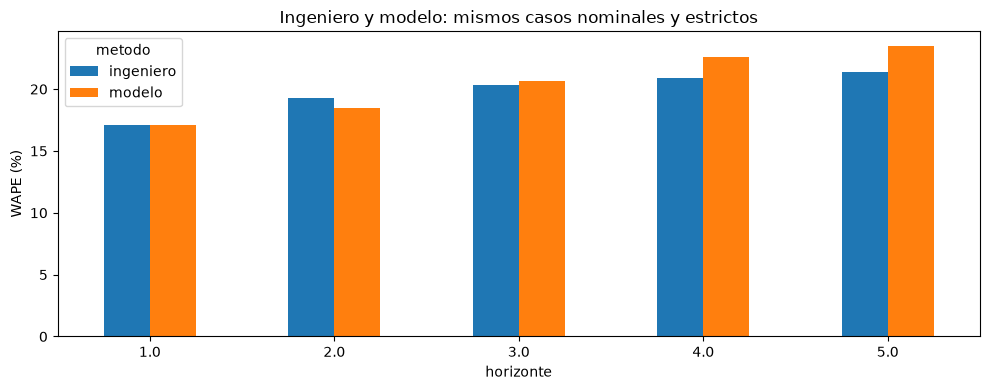

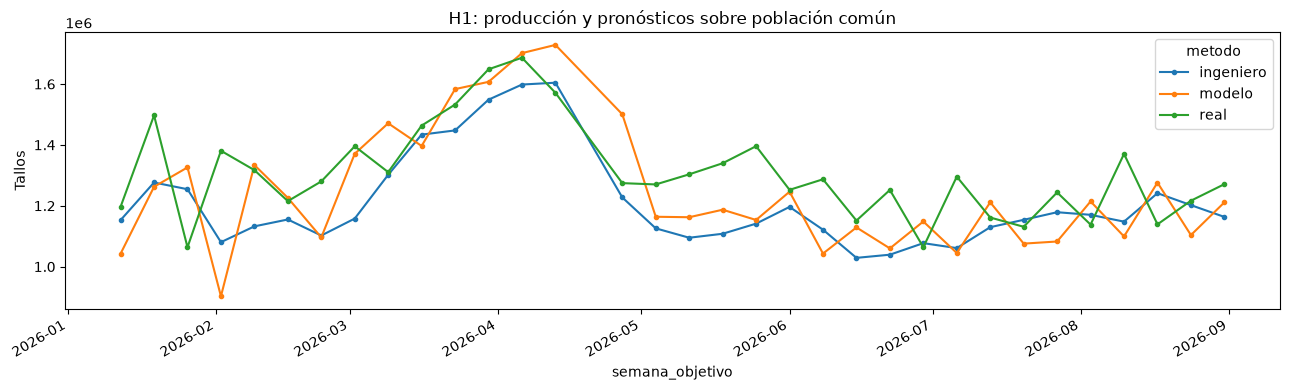

In [5]:
validos=auditoria.loc[auditoria.completo.fillna(False)&auditoria.ingeniero.notna()].copy()
larga=validos.melt(id_vars=llave+['y','ruta','grupo_comparacion'],value_vars=['ingeniero','modelo'],var_name='metodo',value_name='prediccion')
assert larga.groupby(llave).metodo.nunique().eq(2).all()
def metricas(g):
    error=g.y-g.prediccion
    positivos=g.y.gt(0)
    return pd.Series({'n':len(g),'MAE':error.abs().mean(),'RMSE':np.sqrt((error**2).mean()),'WAPE':error.abs().sum()/g.y.sum() if g.y.sum()>0 else np.nan,'sesgo':error.mean(),'dentro_8pct':(error[positivos].abs()<=.08*g.loc[positivos,'y']).mean()})
resumen=larga.groupby(['grupo_comparacion','metodo']).apply(metricas)
principal=larga.loc[larga.grupo_comparacion.eq('principal_estricta_nominal')].copy()
assert len(principal)>0
por_horizonte=principal.groupby(['horizonte','metodo']).apply(metricas)
por_mes=principal.groupby([principal.origen.dt.to_period('M').astype(str).rename('mes'),'metodo']).apply(metricas)
por_producto=principal.groupby(['producto','metodo']).apply(metricas)
por_color=principal.groupby(['producto','color','metodo']).apply(metricas)
por_variedad=principal.groupby(KEY+['metodo']).apply(metricas)
display(resumen);display(por_horizonte);display(por_mes);display(por_producto)
display(principal.groupby(['ruta','metodo']).apply(metricas))
display(por_color);display(por_variedad.head(40))
cobertura=auditoria.groupby('horizonte').agg(modelo=('y','size'),principal=('grupo_comparacion',lambda s:s.eq('principal_estricta_nominal').sum()))
cobertura['observados']=universo.groupby('horizonte').size()
cobertura['pct_principal_sobre_observados']=100*cobertura.principal/cobertura.observados
display(cobertura)
por_horizonte.WAPE.unstack().mul(100).plot.bar(figsize=(10,4),ylabel='WAPE (%)',title='Ingeniero y modelo: mismos casos nominales y estrictos',rot=0)
plt.tight_layout();plt.show()
# Sólo H1: una producción objetivo por serie, sin sumar horizontes.
semanal=principal.loc[principal.horizonte.eq(1)].groupby(['semana_objetivo','metodo']).agg(prediccion=('prediccion','sum'),real=('y','sum'))
vista=semanal.prediccion.unstack();vista['real']=semanal.real.unstack().iloc[:,0]
vista.plot(figsize=(13,4),marker='.',title='H1: producción y pronósticos sobre población común',ylabel='Tallos');plt.tight_layout();plt.show()


## 4. ¿Somos mejores? Resultado calculado y exportación

Una diferencia positiva favorece al modelo. El remuestreo agrupa por semana objetivo para mantener juntas las predicciones de un mismo target; el intervalo es exploratorio porque quedan dependencias temporales. Los periodos ya examinados pertenecen a desarrollo retrospectivo.

In [6]:
m=principal.groupby('metodo').apply(metricas)
delta=100*(m.loc['ingeniero','WAPE']-m.loc['modelo','WAPE'])
print(f'WAPE ingeniero: {100*m.loc["ingeniero","WAPE"]:.2f}% | modelo: {100*m.loc["modelo","WAPE"]:.2f}% | diferencia: {delta:.2f} puntos a favor del modelo.')
print('Conclusión en esta población:', 'el modelo reduce el error' if delta>0 else 'el modelo no mejora al ingeniero')
principal['absoluto']=(principal.y-principal.prediccion).abs()
bloques=principal.groupby(['semana_objetivo','metodo']).agg(error=('absoluto','sum'),real=('y','sum'))
err=bloques.error.unstack();real=bloques.real.unstack().iloc[:,0]
rng=np.random.default_rng(42);diferencias=[]
for _ in range(1000):
    idx=rng.integers(0,len(err),len(err));w=err.iloc[idx].sum()/real.iloc[idx].sum()
    diferencias.append(100*(w.ingeniero-w.modelo))
print('Intervalo exploratorio 95% de diferencia:',np.quantile(diferencias,[.025,.975]))
print('Orígenes evaluados:',predicciones.origen.min(), 'a',predicciones.origen.max())
print('No generalizar a series excluidas, entregas posteriores ni exportable sin confirmar unidades y disponibilidad.')
auditoria.to_parquet(DESTINO/'comparacion_ingeniero_modelo_2026.parquet',index=False)
with pd.ExcelWriter(DESTINO/'comparacion_ingeniero_modelo_2026.xlsx') as writer:
    for nombre,tabla in {'Resumen':resumen,'Horizonte':por_horizonte,'Mes':por_mes,'Producto':por_producto,'Color':por_color,'Variedad':por_variedad,'Cobertura':cobertura,'H1_semanal':vista}.items():tabla.to_excel(writer,sheet_name=nombre)
    auditoria.to_excel(writer,sheet_name='Casos_y_exclusiones',index=False)
print('Resultados:',DESTINO/'comparacion_ingeniero_modelo_2026.xlsx')


WAPE ingeniero: 19.74% | modelo: 20.36% | diferencia: -0.62 puntos a favor del modelo.
Conclusión en esta población: el modelo no mejora al ingeniero


Intervalo exploratorio 95% de diferencia: [-2.02578083  0.76755628]
Orígenes evaluados: 2026-01-05 00:00:00 a 2026-08-31 00:00:00
No generalizar a series excluidas, entregas posteriores ni exportable sin confirmar unidades y disponibilidad.


Resultados: C:\Materias y Cosas Técnicas Uniandes\Proyecto de grado\Proyecto de grado 2\Datos_analiticos_proyecto\modelo_con_proyecciones_teoricas\comparacion_ingeniero_modelo_2026.xlsx
